# 1) Topology optimization with homogenization

____
|**<u>Indicative duration</u>** : 1 hour 30 minutes
|---|

There are 4 types of code cells:
- **<font color='green'>[RUN & OBSERVE]</font>** $\rightarrow$ the cell should be run directly without modification
- **<font color='orange'>[RUN & PLAY]</font>** $\rightarrow$ the cell can be run directly, but some parameters should be changed interactively
- **<font color='red'>[FILL & RUN]</font>**    $\rightarrow$ the cell should be filled before being run
- **<font color='magenta'>[FILL & PLAY]</font>** $\rightarrow$ the cell should be filled, and then some parameters should be changed interactively.

____
## A) Problem definition

|**<u>Indicative duration</u>** : 40 minutes|
|---|

The objective is to design a **<u>transformer</u>**, so to distribute iron in order to **<u>maximize the magnetic flux</u>** that is coming from the primary winding into the secondary winding.

With [density method](2_SIMP.ipynb) we use intermediate materials **<u>without physical interpretation</u>**. **Homogenization** theory gives an interpretation in terms of **microstructure**.

### i) Design domain

Consider the 2D domain $\Omega$ with a boundary $\partial \Omega$, containing a primary winding $P$ with back-and-forth conductors $P_+$ and $P_-$, as well as a secondary winding with back-and-forth conductors $S_+$ and $S_-$. 
The coils are fixed and the design zone is called $\Omega_c$.

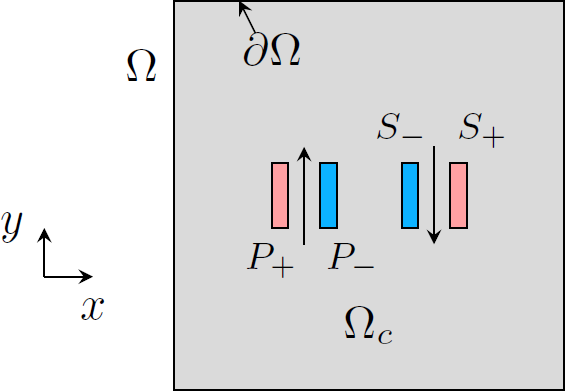

|**<font color='green'>[RUN & OBSERVE]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 1 : Import transformer mesh
###############################################################################

from utils.geometry import transformer
from ngsolve.webgui import Draw

mesh = transformer(maxh = 1e-2)                   #  mesh the transformer geometry
print(f"Region names : {mesh.GetMaterials()}")   # display the regions (materials) labels
print(f"Line names : {mesh.GetBoundaries()}")    # display the lines (boundaries) labels
Draw(mesh)

___
### ii) Rank-1 laminate

Consider a rank-1 laminate microstructure, which is a sandwich of linear iron and air. Then, the macroscopic magnetic behavior is equivalent to an **<u>anisotropic tensor reluctivity</u>**.

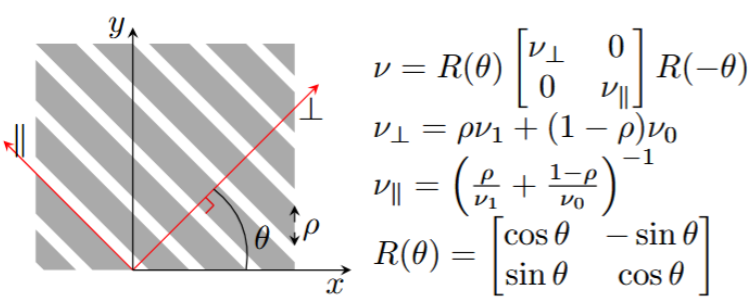

Two parameters are necessary to describe this homogenized tensor on each point of $\Omega_c$:
- The volume fraction of iron $\rho \in [0,1]$
- The fiber orientation $\theta\in[0,2\pi]$

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 2 : Define homogenized material property
###############################################################################


from ngsolve import cos, sin, pi, CF
from ngsolve import CoefficientFunction as CF

nu0 = 1/(4e-7 * pi)
nuIron = nu0/1000

def R(theta):
    """ Rotation matrix of angle theta """
    return CF( ( (cos(theta), -sin(theta)), (sin(theta), cos(theta)) ), dims = (2,2) )

def tR(theta):
    """ Rotation matrix of angle -theta """
    return R(-theta)

def diag(c11, c22):
    """ Diagonal matrix """
    return CF( ((c11, 0), (0, c22) ), dims = (2,2))

def nu_serial(rho): 
    """ Arithmetic mean of reluctivity """
    return (1-rho) * nu0 + rho * nuIron

def nu_parallel(rho) :
    """ Harmonic mean of reluctivity """
    return 1/( (1-rho) / nu0 + rho/nuIron )

def nu_diag(rho):
    """ Reluctivity tensor in local basis """
    return diag(nu_serial(rho), nu_parallel(rho))
    
def nu(rho,theta):
    """ Homogenized reluctivity tensor """
    return R(theta) * nu_diag(rho) * tR(theta)
    
# Vizualize the material field
from utils.solver import DrawMaterial

        
from ngsolve import GridFunction, L2
fes_rho_theta = L2(mesh, definedon = "Omega_c")
rho, theta = GridFunction(fes_rho_theta), GridFunction(fes_rho_theta)
rho.Set(CF(0.5))
theta.Set(-pi/2)
DrawMaterial(rho,theta)

### iii) Magnetic state

The magnetic state depends on the fields $\rho$ and $\theta$ implicitely by solving the state equation

$$
\text{find $a_{\rho,\theta} \in H^1_0(\Omega)$, such that }
$$
$$
\forall v \in H^1_0(\Omega), \quad  \mathcal R(a_{\rho,\theta}, v, \rho, \theta) = \int_\Omega \text{curl}\;v \cdot \nu(\rho, \theta) \text{curl}\;a_{\rho,\theta} - \int_{P_+} v j + \int_{P_-} v j = 0,
$$

with $j = 10^6 A/m²$, and $\mathcal R(a, v, \rho, \theta)$ the residual. To highligh the implicit dependance in $\rho$ and $\theta$, we write $a_{\rho, \theta}$.


|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 3 : Define the magnetostatic solver
###############################################################################

j = 1e6 # current density in the primary coil (A/m²)

from ngsolve import CF, grad

def curl(v):
    R = CF(((0,1),(-1,0)), dims = (2,2))  # Rotation matrix of angle -pi/2
    return R * grad(v)

from ngsolve import H1, BilinearForm, LinearForm, dx
from utils.solver import solve

def state(rho, theta):
    """ Solve the state equation for given fields rho and theta """
    fes = H1(mesh, order = 1, dirichlet = "dOmega")
    a, v = fes.TnT()    # define the trial and test functions 
    bf = BilinearForm(curl(v) * (nu(rho, theta) * curl(a)) * dx)  
    lf = LinearForm(j * v * dx("Pp") - j * v * dx("Pm"))
    return solve(bf, lf)

# Test your function
a_rho_theta, Kinv = state(rho, theta)
Draw(a_rho_theta)

### iv) Objective function

We want to maximize the magnetic flux, which is
$$\phi(a) = L_z N_s \left(\frac{1}{|S^+|} \int_{S^+} a - \frac{1}{|S^-|}\int_{S^-} a \right)$$
with $N_s$ the number of turns of the secondary winding, and $L_z$ the length of the transformer in the $z$ direction (normalized to $L_z = 1m$ here). To comply with optimization customs and traditions, we define 
$$f(\rho) := -\phi(a_\rho)$$
the objective function to **<u>minimize</u>**.

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 4 : Compute the flux
###############################################################################

from ngsolve import Integrate

Ns = 100   # turns
Lz = 1     # z-length (normalized to 1m)

Sp = Integrate(1, mesh, definedon = mesh.Materials("Sp"))
Sm = Integrate(1, mesh, definedon = mesh.Materials("Sm"))

def flux(sol):
    """ Compute the flux in the secondary coil """
    aSp = Integrate(sol, mesh, definedon = mesh.Materials("Sp"))
    aSm = Integrate(sol, mesh, definedon = mesh.Materials("Sm"))
    return Ns * Lz * (aSp/Sp - aSm/Sm)

def f(rho, theta, sol = None):
    """ Objective function to minimize """
    if sol is None:     # compute the state if not given
        sol, _ = state(rho, theta)
    return -flux(sol)

# Test your function
print(f"Secondary flux =  {flux(a_rho_theta):.3e} Wb/m")
print(f"Objective      = {f(rho, theta):.3e} Wb/m")

____
### v) Optimization problem

We are now able to state the optimization problem mathematically:

$$\text{find}\; \rho^*, \theta^* = \arg \min_{\substack{\rho:\Omega_c\rightarrow [0,1]\\\theta:\Omega_c\rightarrow [0,2\pi]}} - L_z N_s \left(\frac{1}{|S^+|} \int_{S^+} a_{\rho,\theta} - \frac{1}{|S^-|}\int_{S^-} a_{\rho,\theta} \right)$$

with 
$$\forall v \in H^1_0(\Omega), \quad \int_\Omega \text{curl}\;v \cdot \nu(\rho,\theta) \text{curl}\;a_{\rho,\theta} - \int_{P_+} v j + \int_{P_-} v j = 0$$

We can solve this problem numerically with a **<u>[gradient descent](https://en.wikipedia.org/wiki/Gradient_descent)</u>**.

___
## B) Transformer optimization

### i) Derivative computation

Again, we compute the derivative with adjoint method.

In [ ]:
###############################################################################
## CODE CELL 4 : Adjoint state
###############################################################################

from utils.optimization import solve_adjoint

def df(state, rho, a):
    """ directional derivative of the objective function """
    return - Ns * Lz * (a/Sp * dx("Sp") - a/Sm * dx("Sm"))

# Test your function
v_rho = solve_adjoint(a_rho_theta, rho, Kinv, df)
Draw(v_rho)

#### Directional derivatives

Similarly to the [density method](2_SIMP.ipynb), we compute directional derivatives o

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 65: Directional derivatives
############################################################################### 

def drho_f(state, adjoint, rho, theta):
    """ directional derivative of the objective function """
    fes = rho.space
    drho = fes.TestFunction()
    f_prime = LinearForm(fes)
    f_prime += curl(adjoint) * ( nu(rho, theta).Diff(rho) * curl(state) ) * drho * dx  # directional derivative
    f_prime.Assemble()
    return f_prime  # return the linear form

def dtheta_f(state, adjoint, rho, theta):
    """ directional derivative of the objective function """
    fes = theta.space
    dtheta = fes.TestFunction()
    f_prime = LinearForm(fes)
    f_prime += curl(adjoint) * ( nu(rho, theta).Diff(theta) * curl(state) ) * dtheta * dx  # directional derivative
    f_prime.Assemble()
    return f_prime  # return the linear form

def df_drho(a_rho_theta, rho, theta, Kinv):
    """ Encapsulate derivative computation w.r.t rho"""
    v_rho_theta = solve_adjoint(a_rho_theta, rho, Kinv, df)
    riesz_representer = GridFunction(rho.space)
    riesz_representer.vec.data = drho_f(a_rho_theta, v_rho_theta, rho, theta).vec
    return riesz_representer

def df_dtheta(a_rho_theta, rho, theta, Kinv):
    """ Encapsulate derivative computation w.r.t theta"""
    v_rho_theta = solve_adjoint(a_rho_theta, rho, Kinv, df)
    riesz_representer = GridFunction(rho.space)
    riesz_representer.vec.data = dtheta_f(a_rho_theta, v_rho_theta, rho, theta).vec
    return riesz_representer

# Test the function
dfdrho = df_drho(a_rho_theta, rho, theta, Kinv)
Draw(dfdrho)
dfdtheta = df_dtheta(a_rho_theta, rho, theta, Kinv)
Draw(dfdtheta)

#### Descent direction

We should then find descent directions for $\theta$ and $\rho$.

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 8 : Descent direction
############################################################################### 

def descent(F_prime, 
            P : callable = lambda x : x):
    """ descent direction """
    d = GridFunction(F_prime.space)
    d.vec.data -= P(F_prime.vec)
    return d

# Test your function with P = lambda x: np.sign(x)
import numpy as np
descent_rho = descent(dfdrho, P = lambda x : np.sign(x))
Draw(descent_rho, mesh)

descent_theta = descent(dfdtheta, P = lambda x : np.sign(x))
Draw(descent_theta, mesh)


______
### ii) Unconstrained optimization


|**<font color='orange'>[RUN & PLAY]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 9 : Unconstrained optimization
############################################################################### 

from utils.optimization import gradient_descent2

rho, theta = GridFunction(fes_rho_theta), GridFunction(fes_rho_theta)
rho.Set(CF(0.5))
theta.Set(-pi/2)

sol = gradient_descent2(state, f, 
                        df_drho, df_dtheta,
                        rho0= rho, theta0 = theta,
                        descent_rho = lambda x : descent(x, lambda y : np.sign(y)),
                        descent_theta = lambda x : descent(x, lambda y : np.pi*np.sign(y)),
                        step = 0.1,
                        step_max = 0.2,
                        maxit = 100
                        )

______
### iii) Constrained optimization (penalization)

The optimized transformer is far too big! So we apply a volume (mass) constraint that reads
$$ m(\rho) = \frac{\int_{\Omega_c} \rho}{\int_{\Omega_c} 1}$$

Its directional derivative simply reads
$$ m'(\rho; \delta \rho) = \frac{\int_{\Omega_c} \delta \rho}{\int_{\Omega_c} 1} $$

Plot the Riesz representer of the directional derivative: how can we interpret this field?

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 10 :Constrained optimization algorithm
############################################################################### 

def m(rho, zone = "Omega_c"):
    """ mass function """
    return Integrate(rho*dx(zone), mesh)/Integrate(1, mesh, definedon = mesh.Materials(zone))

def m_prime(rho, zone = "Omega_c"):
    """ directional derivative of the mass function """
    fes = rho.space
    drho = fes.TestFunction()
    mprime = LinearForm(fes)
    mprime += drho * dx(zone)  # directional derivative
    mprime.Assemble()
    return mprime  # return the linear form

def m_derivative(rho):
    """ Encapsulate mass derivative computation """
    riesz_representer = GridFunction(rho.space)
    riesz_representer.vec.data = m_prime(rho).vec
    return riesz_representer

# Test the function
Draw(m_derivative(rho))  # we see the area of each triangle!

The mass-penalized optimization problem then reads

$$\text{find}\; \rho^* = \arg \min_{\substack{\rho:\Omega_c\rightarrow [0,1]\\\theta:\Omega_c\rightarrow [0,2\pi]}} f(\rho,\theta) + \frac{\beta}{2} \max(0, m(\rho) - m_0)^2$$

with 
$$\forall v \in H^1_0(\Omega), \quad \int_\Omega \text{curl}\;v \cdot \nu(\rho) \text{curl}\;a_{\rho,\theta} - \int_{P_+} v j + \int_{P_-} v j = 0$$

To solve it we need to redefine our objective function and its derivative.


|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 11 : Compute the objective functions and its derivatives
############################################################################### 

m0 = 0.1     # target mass
beta = 10   # penalization coefficient

def f_penalized(rho, theta, sol = None, m0 = m0, beta = beta):
    """ Objective function to minimize with mass penalization """
    if sol is None:     # compute the state if not given
        sol, _ = state(rho)
    return -flux(sol) + beta/2 * max(0, m(rho)-m0)**2

def df_dtheta_penalized(a_rho_theta, rho, theta, Kinv):
    """ Encapsulate derivative computation w.r.t rho"""
    v_rho_theta = solve_adjoint(a_rho_theta, rho, Kinv, df)
    riesz_representer = GridFunction(theta.space)
    riesz_representer.vec.data = dtheta_f(a_rho_theta, v_rho_theta, rho, theta).vec 
    return riesz_representer

def df_drho_penalized(a_rho_theta, rho, theta, Kinv):
    """ Encapsulate derivative computation w.r.t rho"""
    v_rho_theta = solve_adjoint(a_rho_theta, rho, Kinv, df)
    riesz_representer = GridFunction(rho.space)
    riesz_representer.vec.data = drho_f(a_rho_theta, v_rho_theta, rho, theta).vec  + beta * max(0, m(rho)-m0) * m_derivative(rho).vec
    return riesz_representer

# Test your function
Draw(df_drho_penalized(a_rho_theta, rho, theta, Kinv))
Draw(df_dtheta_penalized(a_rho_theta, rho, theta, Kinv))

Then, we rerun the optimization algorithm with the new penalized function.


|**<font color='orange'>[RUN & PLAY]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 12 : Penalized optimization algorithm
############################################################################### 

# I nitialization
rho, theta = GridFunction(fes_rho_theta), GridFunction(fes_rho_theta)
rho.Set(CF(0.5))
theta.Set(-pi/2)

sol = gradient_descent2(state, f_penalized, 
                        df_drho_penalized, df_dtheta_penalized,
                        rho0= rho, theta0 = theta,
                        descent_rho = lambda x : descent(x, lambda y : np.sign(y)),
                        descent_theta = lambda x : descent(x, lambda y : np.pi*np.sign(y)),
                        step = 0.1,
                        step_max = 0.2,
                        maxit = 100
                        )

___
## C) Reversed transformer optimization

For an electrical engineer, the obtained result obtained is not so surprising and can be easily interpreted. 

To add some fun, let's test the algorithm for more **unconventional situations**. For example, how would the iron be distributed if we wanted to **reverse** the direction of the flux in the secondary coil without changing the windings?

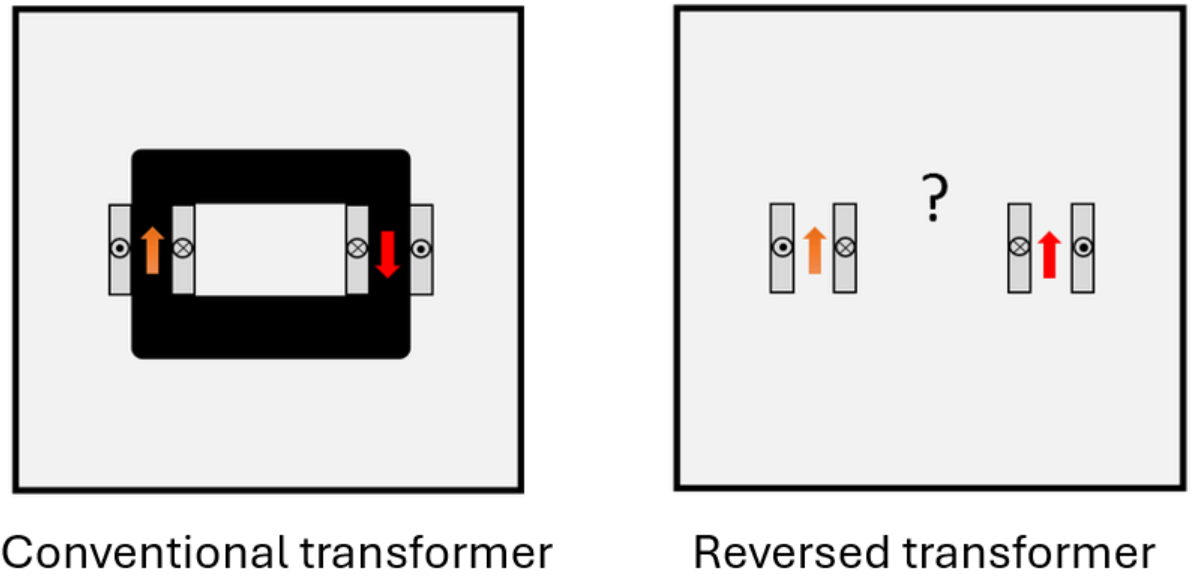

First, let's code this alternative objective function and its derivative.

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 13 : Compute the reversed objective function and its derivatives
############################################################################### 

m0 = 0.1     # target mass
beta = 1   # penalization coefficient

def f_reversed_penalized(rho, theta, sol = None, m0 = m0, beta = beta):
    """ Objective function to minimize with mass penalization """
    if sol is None:     # compute the state if not given
        sol, _ = state(rho, theta)
    return flux(sol) + beta/2 * max(0, m(rho)-m0)**2


def df_dtheta_reversed_penalized(a_rho_theta, rho, theta, Kinv):
    """ Encapsulate derivative computation w.r.t rho"""
    v_rho_theta = solve_adjoint(a_rho_theta, rho, Kinv, df)
    riesz_representer = GridFunction(theta.space)
    riesz_representer.vec.data = -dtheta_f(a_rho_theta, v_rho_theta, rho, theta).vec 
    return riesz_representer

def df_drho_reversed_penalized(a_rho_theta, rho, theta, Kinv):
    """ Encapsulate derivative computation w.r.t rho"""
    v_rho_theta = solve_adjoint(a_rho_theta, rho, Kinv, df)
    riesz_representer = GridFunction(rho.space)
    riesz_representer.vec.data = -drho_f(a_rho_theta, v_rho_theta, rho, theta).vec  + beta * max(0, m(rho)-m0) * m_derivative(rho).vec
    return riesz_representer


# Test your function
Draw(df_dtheta_reversed_penalized(a_rho_theta, rho, theta, Kinv))
Draw(df_drho_reversed_penalized(a_rho_theta, rho, theta, Kinv))

Then, we rerun the optimization algorithm with the new penalized function.


|**<font color='orange'>[RUN & PLAY]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 14 : Penalized optimization algorithm
############################################################################### 

# Initialization
rho = GridFunction( L2(mesh, definedon = "Omega_c") )
theta = GridFunction( L2(mesh, definedon = "Omega_c") )
rho.Set(0.5)
theta.Set(-pi/2)

# play with the parameters...
sol = gradient_descent2(state, f_reversed_penalized, 
                        df_drho_reversed_penalized, df_dtheta_reversed_penalized,
                        rho0= rho, theta0 = theta,
                        descent_rho = lambda x : descent(x, lambda y : np.sign(y)),
                        descent_theta = lambda x : descent(x, lambda y : np.pi*np.sign(y)),
                        step = 0.1,
                        step_max = 0.2,
                        maxit = 500
                        )